# # Laboratory Activity 2 - Exploring the Interplay of Lifestyle, Academic, and Psychological Factors on Students

This notebook is a complete worked example for the Logistic Regression laboratory activity using the dataset requested by the instructor.

### Dataset Source
- **Kaggle:** [Student Depression Dataset](https://www.kaggle.com/code/saifeldeenmohammedm/student-depression-dataset)
- **Activity Link:** [School Activities](https://github.com/BSDSA-ISU/case-study)

### Classification Task
Predict whether a student is classified as:

- **Depressed**
- **Not Depressed**

based on certain habits.

### Important Modeling Note
The column **`Name of Student`** is an identifier rather than a meaningful predictive characteristic. It will therefore be excluded from the Logistic Regression model instead of being encoded.

## 1. Import library and Import the dataset

In [138]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Eda
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
df = pd.read_csv("./student_depression_dataset.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,suicidal thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


## 2. Dataset Context and Description

The dataset contains results from **mock job interviews of 2,982 students** in the Philippines. Each student is rated on eight interview-related characteristics. The final `CLASS` variable indicates whether the student was classified as **Employable** or **LessEmployable**.

The eight predictive ratings are:

1. `Profession`
2. `Academic Pressure`
3. `Work Pressure`
4. `CGPA`
5. `Study Satisfaction`
6. `Job Satisfaction`
7. `Sleep Duration`
8. `Dietary Habits`
9. `Degree`
10. `suicidal thoughts`
11. `Work/Study Hours`
12. `Financial Stress`
13. `Family History of Mental Illness`

## Target Variable

`Depression`

- `0`
- `1`

## Identifier

`id`

This variable identifies individual records but does not represent an Depression cause. It is excluded from the predictive model.


## 3. Problem Statement and Objectives

### Problem Statement

To investigate if certain factor can cause depressions on students

## General Objective

To develop and evaluate a Logistic Regression model that predicts student employability classification using mock job-interview performance ratings.

## Specific Objectives

1. To investigate the relationship between
academic pressure and study satisfaction with
mental health indicators such as suicidal thoughts
among university students.
2. To analyze the
influence of lifestyle factors, including dietary
habits and sleep duration, on student’s psychological
well-being.
3. To assess the impact of work
pressure and financial stress on the prevalence of
suicidal ideation in the student population.
4. To evaluate the correlation between academic performance (CGPA) and mental health status, considering the combined effects of academic and lifestyle stressors.
5. To provide recommendations for mental health support interventions tai

## 4. Initial Data Inspection

In [140]:
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
for column in df.columns:
    print("-", column)


Number of observations: 27,901
Number of columns: 18

Column names:
- id
- Gender
- Age
- City
- Profession
- Academic Pressure
- Work Pressure
- CGPA
- Study Satisfaction
- Job Satisfaction
- Sleep Duration
- Dietary Habits
- Degree
- suicidal thoughts
- Work/Study Hours
- Financial Stress
- Family History of Mental Illness
- Depression


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                27901 non-null  int64  
 1   Gender                            27901 non-null  object 
 2   Age                               27901 non-null  float64
 3   City                              27901 non-null  object 
 4   Profession                        27901 non-null  object 
 5   Academic Pressure                 27901 non-null  float64
 6   Work Pressure                     27901 non-null  float64
 7   CGPA                              27901 non-null  float64
 8   Study Satisfaction                27901 non-null  float64
 9   Job Satisfaction                  27901 non-null  float64
 10  Sleep Duration                    27901 non-null  object 
 11  Dietary Habits                    27901 non-null  object 
 12  Degr

In [142]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149421,40641.175216,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


In [143]:
# Missing-value count and percentage.
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

missing_summary


,Missing_Count,Missing_Percent
id,0,0.0
Gender,0,0.0
Family History of Mental Illness,0,0.0
Financial Stress,0,0.0
Work/Study Hours,0,0.0
suicidal thoughts,0,0.0
Degree,0,0.0
Dietary Habits,0,0.0
Sleep Duration,0,0.0
Job Satisfaction,0,0.0


In [144]:
print("Exact duplicate rows:", df.duplicated().sum())

print(
    "Unique student names:",
    df["id"].nunique()
)
print(
    "Total records:",
    len(df)
)


Exact duplicate rows: 0
Unique student names: 27901
Total records: 27901


### Initial Inspection Interpretation

- The dataset contains **27,901 student records** and **18 columns**.
- The dataset contains no conventional missing values.
- Exact duplicate rows are checked before any modeling decisions are made.
- `suicidal thoughts`, `Family History of Mental Illness`, `Dietary Habits` should be converted to numeric codes to be used in regression.


## 5. Data Dictionary and Variable Roles

In [145]:
def build_data_dict(df, target_col=None, id_cols=None):
    id_cols = id_cols or []
    
    summary = pd.DataFrame({
        "Variable": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values,
        "Sample Value": [df[col].dropna().iloc[0] if not df[col].dropna().empty else None for col in df.columns]
    })
    
    # Automatically infer Role
    def assign_role(col):
        if col == target_col:
            return "Target"
        elif col in id_cols or df[col].nunique() == len(df):
            return "Excluded Identifier"
        return "Predictor"
    
    summary["Role"] = summary["Variable"].apply(assign_role)
    return summary

build_data_dict(df, "Depression", "id")

,Variable,Data Type,Missing Values,Unique Values,Sample Value,Role
id,id,int64,0,27901,2,Excluded Identifier
Gender,Gender,object,0,2,Male,Predictor
Age,Age,float64,0,34,33.0,Predictor
City,City,object,0,52,Visakhapatnam,Predictor
Profession,Profession,object,0,14,Student,Predictor
Academic Pressure,Academic Pressure,float64,0,6,5.0,Predictor
Work Pressure,Work Pressure,float64,0,3,0.0,Predictor
CGPA,CGPA,float64,0,332,8.97,Predictor
Study Satisfaction,Study Satisfaction,float64,0,6,2.0,Predictor
Job Satisfaction,Job Satisfaction,float64,0,5,0.0,Predictor


## 6. Proper Data Preprocessing

This dataset requires a slightly different preprocessing strategy from datasets that contain nominal categorical predictors.

### Numerical / Ordinal Predictors

Some Variables are already stored as numbers. They will be:

- checked for valid ranges;
- kept as predictors; and
- standardized using `StandardScaler` **after the train-test split**.

Standardization is not strictly required for Logistic Regression, but it places all coefficients on a more comparable scale and is a good preprocessing practice.

### Non-Numerical Variables

#### `id`

- This is an identifier. It is **dropped**, not encoded.

#### `Dietary Habits`

- This will be converted to numerical values
    - `0 for unhealthy, 1 for moderate, 2 for healthy, and 3 for others`
 
#### `suicidal thoughts`
- This will be converted to numerical
    - `0 for no, 1 for yes`
 
#### `Sleep Duration`
- Converted to:
  - "'More than 8 hours'": 9,
  - "'5-6 hours'": 5.5,
  - "'Less than 5 hours'": 4,
  - "'7-8 hours'": 7.5,
   - "?": 0

#### `Profession`, `Degree`, `City`, `Profession`, `Work Pressure`, `Job Satisfaction` and `Degree`
- only be used in eda
- and `"Profession", "Work Pressure", "Job Satisfaction", "Degree"` is not used since all of the datas are from student

#### `Depression`

- This is the binary target, Already encoded as `0` and `1`

In [146]:
# Convert to numerical fist :)
diet_map = {
    'Unhealthy': 0,
    'Moderate': 1,
    'Healthy': 2,
    'Others': 3
}

suicide_map = {
    'Yes': 0,
    'No': 1
}

sleep_map = {
  "'More than 8 hours'": 9,
  "'5-6 hours'": 5.5,
  "'Less than 5 hours'": 4,
  "'7-8 hours'": 7.5,
}

financial_map = {
    "?": 0,
    "1.0": 1,
    "2.0": 2,
    "3.0": 3,
    "4.0": 4,
    "5.0": 5
}

# Apply the mapping to the column
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)
df['suicidal thoughts'] = df['suicidal thoughts'].map(suicide_map)
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map(suicide_map)
df['Financial Stress'] = df['Financial Stress'].map(financial_map)

target_column = "Depression"
exclude_columns = ["id", target_column]

# Dynamically pick all columns except ID and target
predictor_columns = [col for col in df.columns if col not in exclude_columns]

X = df[predictor_columns].copy()

# Auto-map target using Factorize or LabelEncoder
y = pd.factorize(df[target_column])[0]

print("Predictor shape:", X.shape)
print("Target unique values:", sorted(set(y)))

X.head()

Predictor shape: (27901, 16)
Target unique values: [np.int64(0), np.int64(1)]


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,suicidal thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5.5,2,B.Pharm,0,3.0,1,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5.5,1,BSc,1,3.0,2,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,4.0,2,BA,1,9.0,1,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7.5,1,BCA,0,4.0,5,0
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5.5,1,M.Tech,0,1.0,1,1


# 7. Data Quality and Valid-Range Checking

The feature values are mock-interview ratings. Before modeling, their actual observed ranges should be checked for impossible or unexpected values.


In [147]:
range_table = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Unique_Values": [
        sorted(X[column].unique().tolist())
        for column in X.columns
    ]
})

range_table


,Minimum,Maximum,Unique_Values
Gender,Female,Male,"[Female, Male]"
Age,18.0,59.0,"[18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25...."
City,'Less Delhi',Visakhapatnam,"['Less Delhi', 'Less than 5 Kalyan', 3.0, Agra..."
Profession,'Civil Engineer',Teacher,"['Civil Engineer', 'Content Writer', 'Digital ..."
Academic Pressure,0.0,5.0,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0]"
Work Pressure,0.0,5.0,"[0.0, 2.0, 5.0]"
CGPA,0.0,10.0,"[0.0, 5.03, 5.06, 5.08, 5.09, 5.1, 5.11, 5.12,..."
Study Satisfaction,0.0,5.0,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0]"
Job Satisfaction,0.0,4.0,"[0.0, 1.0, 2.0, 3.0, 4.0]"
Sleep Duration,4.0,9.0,"[4.0, 5.5, 7.5, 9.0, nan]"


### Range Interpretation

The observed scores fall within narrow rating scales:

- Most predictor variables contain different integer ranges.
- `Work Pressure` contains scores from **0.0 to 5.0**.
- Map `Financial Stress` `?` to `0`
- `Family History of Mental Illness` has 0 and 1

There are no values outside these observed rating scales. No records are removed on the basis of invalid scores.


## 8. Exploratory Data Analysis (EDA)

### 8.1 Dataset Shape

In [148]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Model predictors:", X.shape[1])


Rows: 27901
Columns: 18
Model predictors: 16


#### Interpretation

this shows that the dataset has `27901` rows and `18` columns.

### 8.2 Missing values

In [149]:
X.isna().sum().to_frame("Missing_Count")

,Missing_Count
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0
Sleep Duration,18


#### Missing-Value Interpretation

There are no missing values among the model predictors. No imputation is required for this dataset.


### 8.3 Target Value Counts and Class Distribution

In [150]:
class_counts = df["Depression"].value_counts()
class_percent = (
    df["Depression"].value_counts(normalize=True) * 100
).round(2)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent
})

class_distribution


,Count,Percent
Depression,,
1,16336,58.55
0,11565,41.45


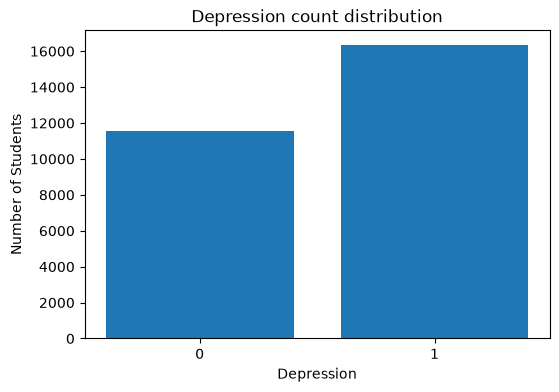

In [151]:
plt.figure(figsize=(6, 4))
plt.bar(
    class_counts.index,
    class_counts.values
)
plt.title("Depression count distribution")
plt.xlabel("Depression")
plt.ylabel("Number of Students")
plt.xticks([0, 1])
plt.show()


#### Class-Distribution Interpretation

The dataset contains more **Depressed(1)** students than **non Depressed(0)** students. The imbalance is noticeable but not extreme
Accuracy should still be interpreted together with precision, recall, F1-score, and the confusion matrix.


### 8.4 Value Counts for Each Interview Rating

In [152]:
for column in predictor_columns:
    print(f"\n--- {column} ---")
    print(
        df[column]
        .value_counts()
        .sort_index()
    )



--- Gender ---
Gender
Female    12354
Male      15547
Name: count, dtype: int64

--- Age ---
Age
18.0    1587
19.0    1560
20.0    2237
21.0    1726
22.0    1160
23.0    1645
24.0    2258
25.0    1784
26.0    1155
27.0    1462
28.0    2133
29.0    1950
30.0    1145
31.0    1427
32.0    1262
33.0    1893
34.0    1468
35.0      10
36.0       7
37.0       2
38.0       8
39.0       3
41.0       1
42.0       4
43.0       2
44.0       1
46.0       2
48.0       3
49.0       1
51.0       1
54.0       1
56.0       1
58.0       1
59.0       1
Name: count, dtype: int64

--- City ---
City
'Less Delhi'               1
'Less than 5 Kalyan'       1
3.0                        1
Agra                    1094
Ahmedabad                951
Bangalore                767
Bhavna                     2
Bhopal                   934
Chennai                  885
City                       2
Delhi                    768
Faridabad                461
Gaurav                     1
Ghaziabad                745
Harsh    

### 8.5 Distribution of Predictor Ratings

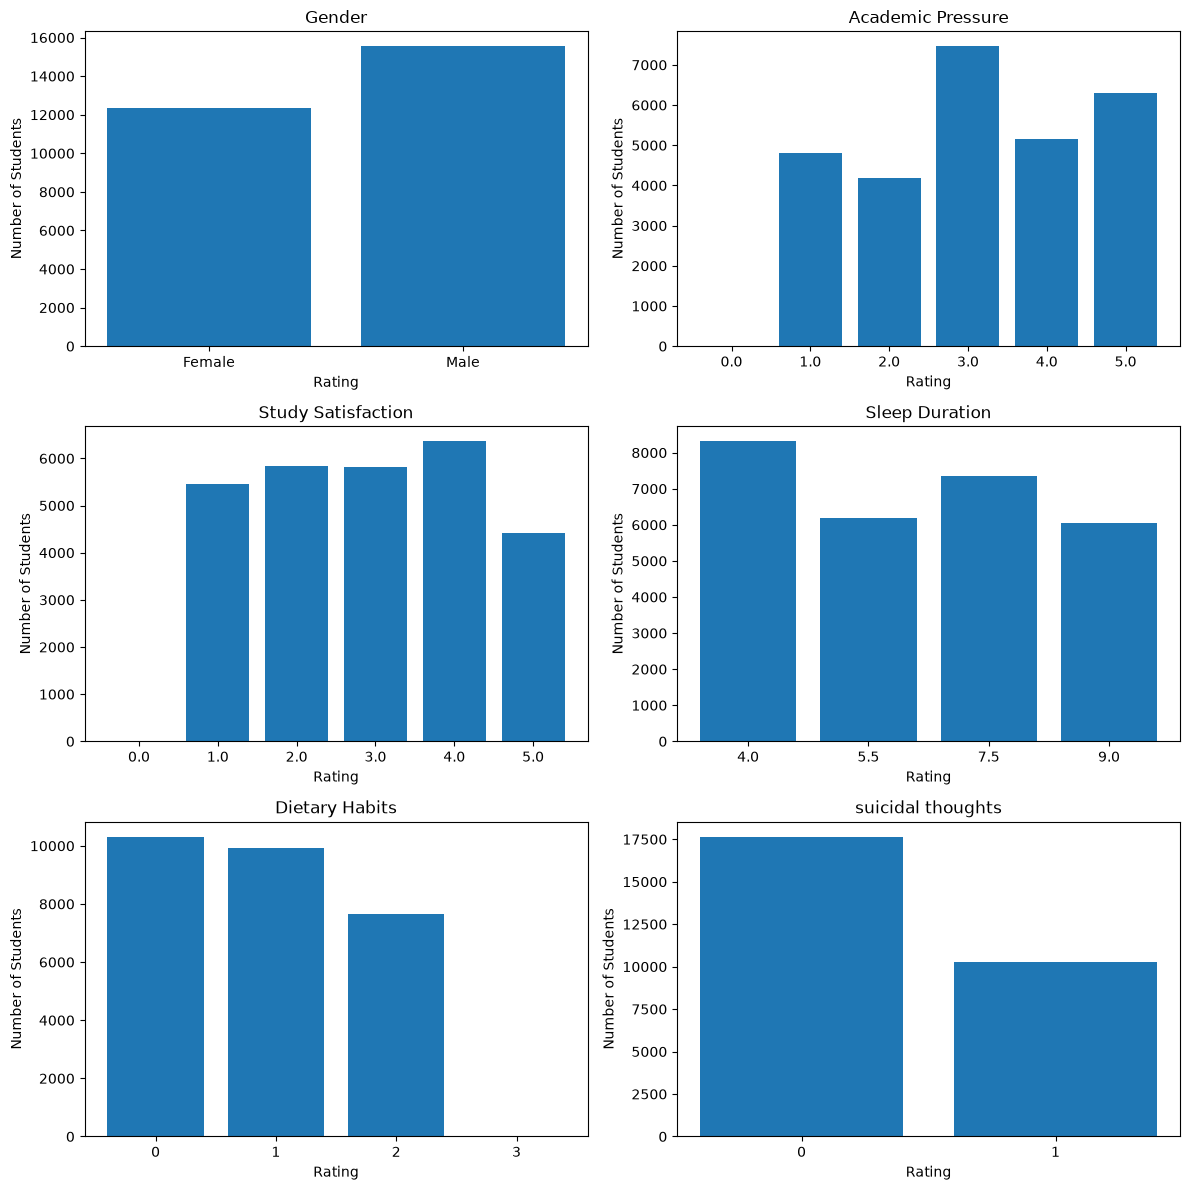

In [153]:
# Filter out 'CGPA' and 'Age'
filtered_columns = [col for col in predictor_columns if col not in ["CGPA", "Age", "City", "Profession", "Work Pressure", "Job Satisfaction", "Degree"]]

# Adjust grid size based on filtered columns (e.g., 6 columns fit in 3x2)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, column in zip(axes.ravel(), filtered_columns):
    counts = df[column].value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(column)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

#### Interpretation

`"CGPA", "Age", "City", "Profession", "Work Pressure", "Job Satisfaction" and "Degree"` are not used on graphings due for them having many ranges.

instead we use other graphs suitable for them.

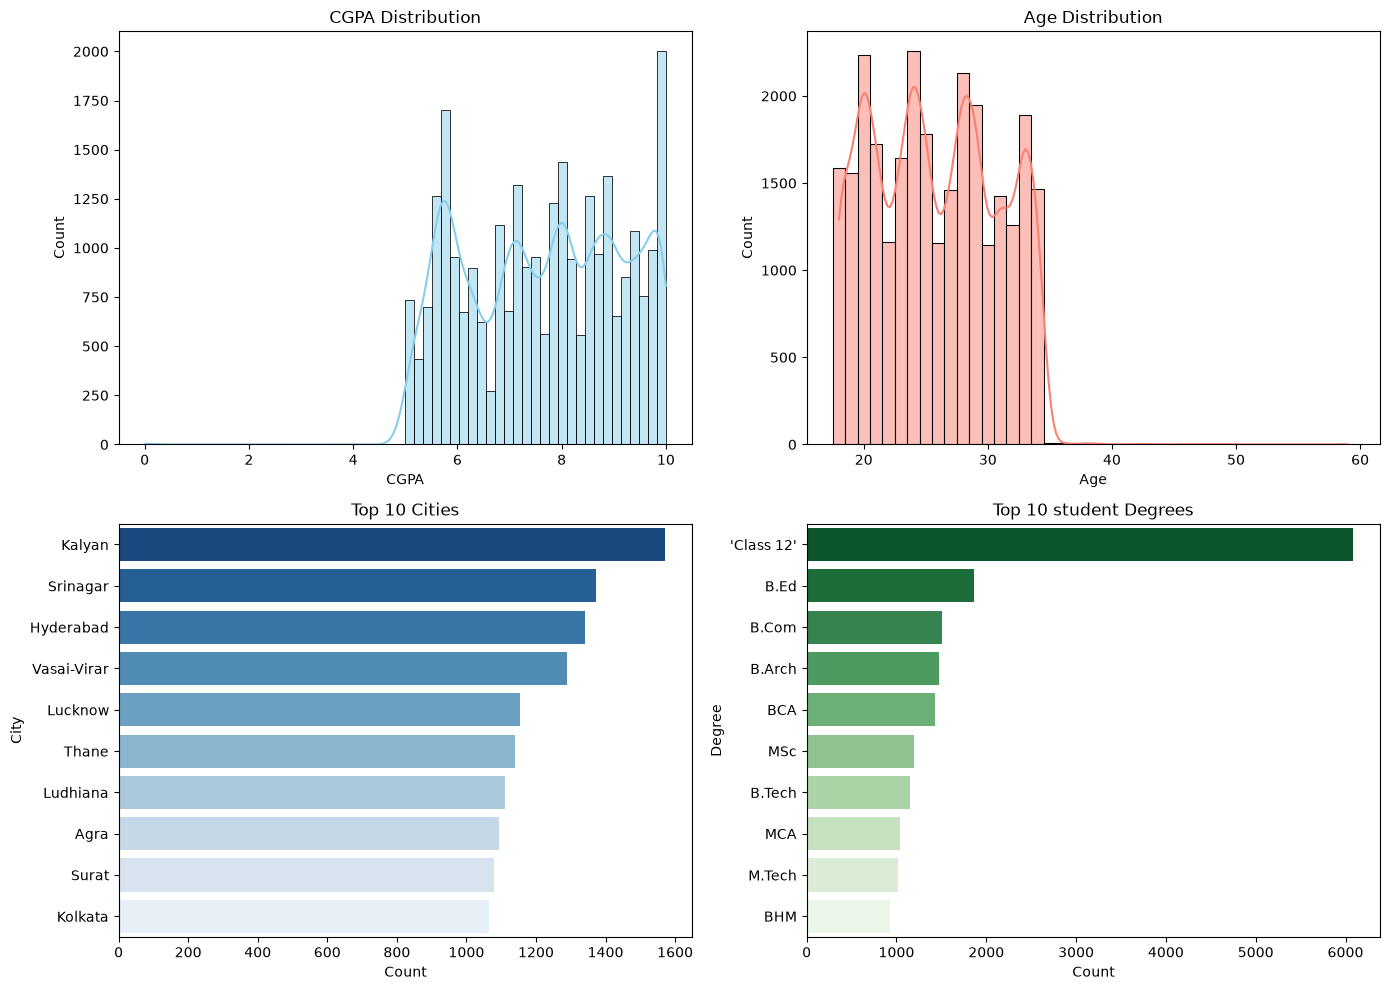

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CGPA: Histogram with KDE curve
sns.histplot(data=df, x="CGPA", kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("CGPA Distribution")
axes[0, 0].set_xlabel("CGPA")

# 2. Age: Histogram with integer binning
sns.histplot(
    data=df, x="Age", kde=True, ax=axes[0, 1], color="salmon", discrete=True
)
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age")

# 3. City: Top 10 Horizontal Bar Chart
top_cities = df["City"].value_counts().head(10)
sns.barplot(
    x=top_cities.values, y=top_cities.index, ax=axes[1, 0], palette="Blues_r"
)
axes[1, 0].set_title("Top 10 Cities")
axes[1, 0].set_xlabel("Count")

# 4. Degree: Top 10 Horizontal Bar Chart
top_professions = df["Degree"].value_counts().head(10)
sns.barplot(
    x=top_professions.values,
    y=top_professions.index,
    ax=axes[1, 1],
    palette="Greens_r",
)
axes[1, 1].set_title("Top 10 student Degrees")
axes[1, 1].set_xlabel("Count")


plt.tight_layout()
plt.show()

### 8.6 Descriptive Statistics

In [155]:
X.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Sleep Duration,27883.0,6.338540,1.917480,4.0,4.00,5.50,7.50,9.0
Dietary Habits,27901.0,0.905308,0.797977,0.0,0.00,1.00,2.00,3.0
suicidal thoughts,27901.0,0.367191,0.482048,0.0,0.00,0.00,1.00,1.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0


#### Descriptive-Statistics Interpretation

The mean and standard deviation summarize the central tendency and spread of each datasets. Because the variables use short ordinal scales, these statistics should be interpreted together with the frequency distributions rather than treated as precise continuous measurements.

### 8.7 Correlation Matrix Among Predictors

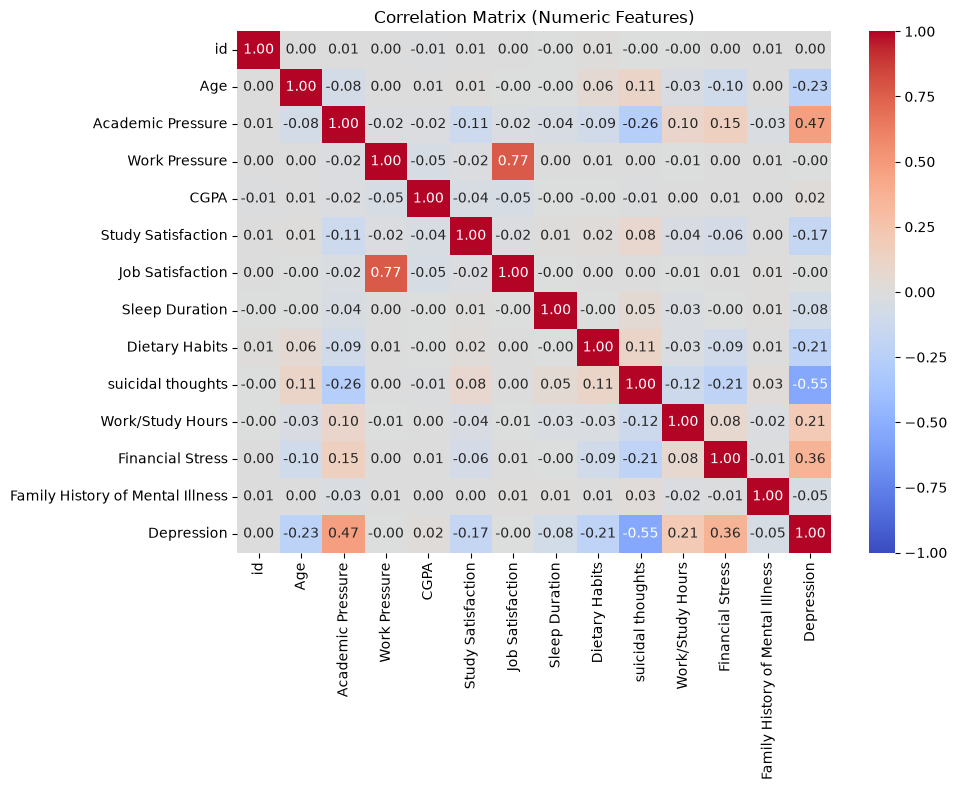

In [156]:
# Compute correlation matrix for numeric columns only
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

### Corelation interpretation

This shows that some variables are sligly positively corelated with `Depression` variable.

**Some variables includes**:
- Academic Pressure: 0.47
- Financial Stress: 0.36
- Work/Study Hours: 0.21

while the rest are negative corelated like `suicidal thoughts` sitting at -0.55.

## 8.8 Depression vs no Depression compare each variable

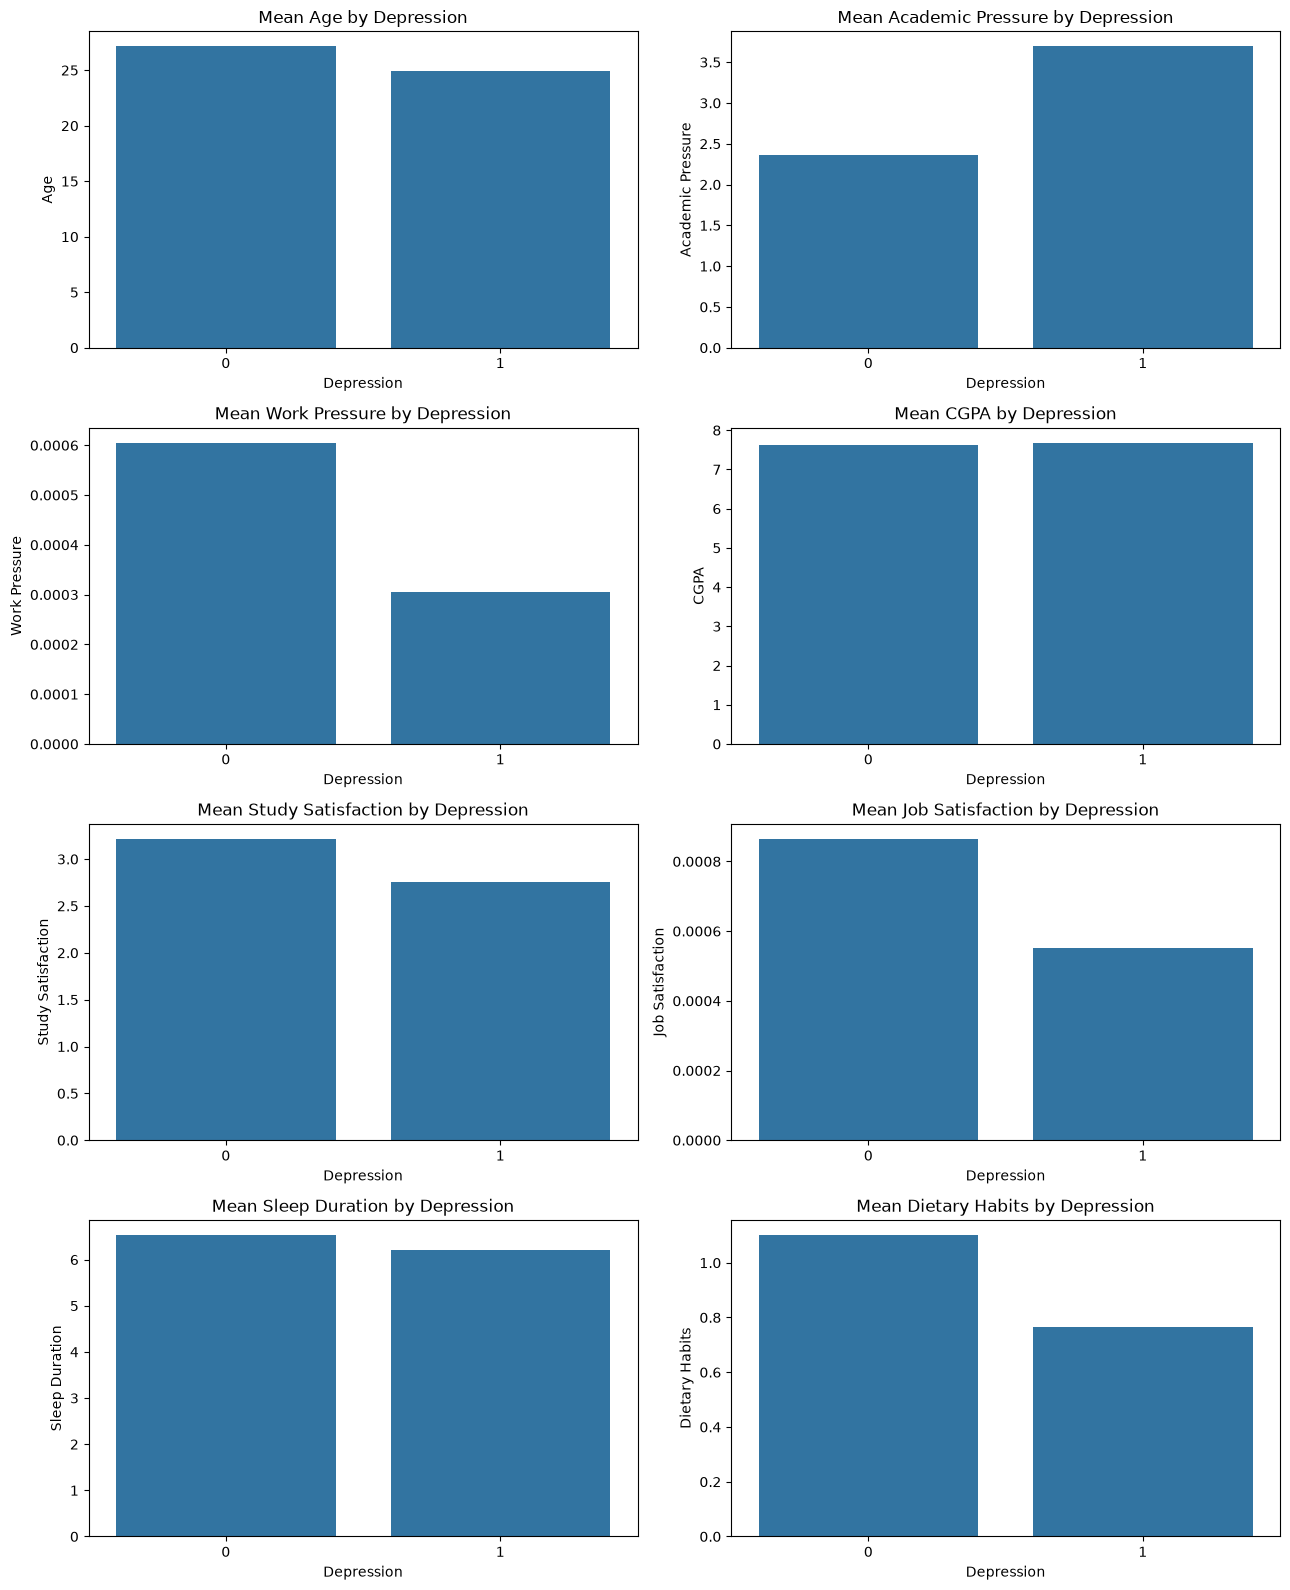

In [157]:
numeric_predictors = [
    col for col in predictor_columns 
    if col in df.select_dtypes(include="number").columns and col not in ["id", "Depression"]
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))


for ax, column in zip(axes.ravel(), numeric_predictors):
    sns.barplot(data=df, x="Depression", y=column, ax=ax, ci=None)
    ax.set_title(f"Mean {column} by Depression")

plt.tight_layout()
plt.show()

## 9. Split the Data into Training and Testing Sets

The dataset will be divided into:

- **80% training data**
- **20% testing data**

Stratification is used so that both subsets retain similar Depressed(1) of Employable and Non depressed(0) students.


In [175]:
X = df.drop(columns=["id", "Depression"])
y = df["Depression"]

# 3. Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 4. Check shapes and class balance
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

X_train shape: (22320, 16)
X_test shape : (5581, 16)
y_train shape: (22320,)
y_test shape : (5581,)

Training class proportions:
Depression
0    0.415
1    0.585
Name: proportion, dtype: float64

Testing class proportions:
Depression
0    0.414
1    0.586
Name: proportion, dtype: float64


### Train-Test Split Interpretation

The training set is used to estimate the Logistic Regression model. The testing set is kept unseen during model training so it can provide a more realistic evaluation of performance on new observations.

## 10. Logistic regression assumption/condition checking

### 10.1. Binary dependent variable

In [159]:
print(
    "Original target values:",
    df["Depression"].unique()
)
print(
    "Encoded target values:",
    sorted(y.unique())
)
print(
    "Number of target classes:",
    y.nunique()
)


Original target values: [1 0]
Encoded target values: [np.int64(0), np.int64(1)]
Number of target classes: 2


**Interpretation:** The target contains exactly two categories and is correctly encoded as 0 and 1. The binary-outcome requirement is satisfied.


### 10.2. Appropriate sample size and class count

In [160]:
sample_size_table = pd.DataFrame({
    "Training": y_train.value_counts().sort_index(),
    "Testing": y_test.value_counts().sort_index()
})

sample_size_table.index = [
    "Non Depressed (0)",
    "Depressed (1)"
]

sample_size_table


,Training,Testing
Non Depressed (0),9252,2313
Depressed (1),13068,3268


#### Sample-Size Interpretation

Both classes have thousands of observations in the test set and more than one thousand total observations in the full dataset. The sample is adequate for fitting a basic Logistic Regression model with eight predictors.

The classes are moderately imbalanced but neither class is extremely rare.


## 11.0 Model evaluation

### 11.1 Preprocessing Pipeline and fitting

In [161]:
# 1. Keep ONLY numeric columns in X
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 3. Add SimpleImputer to fill missing values before scaling
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# 4. Train model
model.fit(X_train, y_train)

# 5. Predict and build summary DataFrame
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_prob = model.predict_proba(X_test)[:, 1]

prediction_sample = pd.DataFrame({
    "Actual_Class": y_test.values,
    "Predicted_Class": y_pred,
    "Probability_Depression": y_prob
})

prediction_sample.head(10)

,Actual_Class,Predicted_Class,Probability_Depression
0,1,1,0.957627
1,0,1,0.739062
2,1,1,0.741186
3,0,0,0.259315
4,1,0,0.392412
5,0,0,0.109634
6,0,0,0.356287
7,0,1,0.875369
8,0,0,0.005446
9,1,1,0.976579


The model pipeline standardizes each predictor using statistics learned from the **training set only**.

This prevents data leakage.

The testing data is transformed using the mean and standard deviation learned from the training data; the testing set does not determine its own scaling parameters.

## # 12. Train the Logistic Regression Model

In [162]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_table = pd.DataFrame(
    cm,
    index=[
        "Actual: LessEmployable",
        "Actual: Employable"
    ],
    columns=[
        "Predicted: LessEmployable",
        "Predicted: Employable"
    ]
)

cm_table


,Predicted: LessEmployable,Predicted: Employable
Actual: LessEmployable,1838,475
Actual: Employable,392,2876


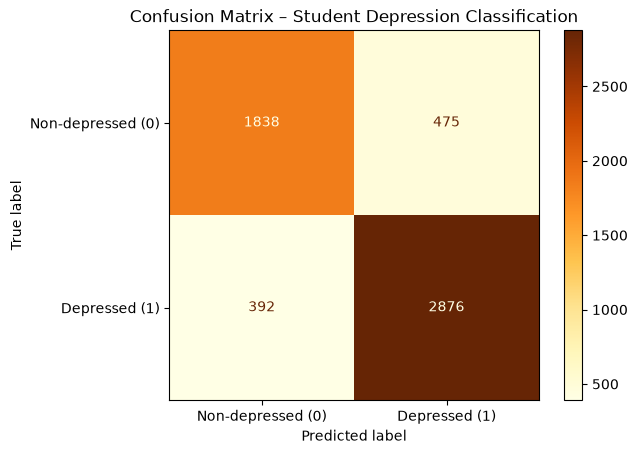

In [172]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-depressed (0)",
        "Depressed (1)"
    ]
)

disp.plot(
    cmap="YlOrBr",
    values_format="d",
    colorbar=True
)

plt.title("Confusion Matrix – Student Depression Classification")
plt.show()

### Confusion Matrix Interpretation

For this model:

- **True Negative (TN):** A non Depressed student correctly predicted as non Depressed.
- **False Positive (FP):** A Depressed student incorrectly predicted as non Depressed.
- **False Negative (FN):** A Depressed student incorrectly predicted as non Depressed.
- **True Positive (TP):** A Employable student correctly predicted as Employable.

The confusion matrix shows not only how many predictions were correct, but also **which type of classification error occurred**.


### 14.1 Accuracy, Precision, F1 score

In [164]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_table


,Metric,Score
0,Accuracy,0.844651
1,Precision,0.858251
2,Recall,0.880049
3,F1-score,0.869013


#### Metric Interpretation

With the fixed split used in this sample:

- **Accuracy** measures the percentage of all test students classified correctly.
- **Precision** measures how often an Depression(1) prediction is actually Depression.
- **Recall** measures how many actual Depression(1) students the model successfully identifies.
- **F1-score** balances precision and recall.

These metrics should be interpreted together rather than selecting a model based only on accuracy.


### 14.3 Classification Report

In [165]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "non depressed",
            "depressed"
        ]
    )
)


               precision    recall  f1-score   support

non depressed       0.82      0.79      0.81      2313
    depressed       0.86      0.88      0.87      3268

     accuracy                           0.84      5581
    macro avg       0.84      0.84      0.84      5581
 weighted avg       0.84      0.84      0.84      5581



#### Classification Report Interpretation

The baseline Logistic Regression model generally performs better at identifying the **Depressed(1)** class than the **Non depressed(0)** class.

This means that some students who are actually not depressed are predicted as Employable. The difference between class-specific recall values is important because overall accuracy alone does not reveal this imbalance in model performance.


In [166]:
# 1. Get the exact fitted logistic regression step
fitted_lr = model.named_steps["classifier"]

# 2. Get the coefficients
coefficients = fitted_lr.coef_[0]

# 3. Use X_train.columns directly to prevent shape mismatches
coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
}).sort_values("Odds_Ratio", ascending=False)

coefficient_table

,Feature,Coefficient,Odds_Ratio
1,Academic Pressure,1.156736,3.179537
10,Financial Stress,0.812221,2.252907
9,Work/Study Hours,0.435503,1.545740
3,CGPA,0.086994,1.090890
5,Job Satisfaction,0.000094,1.000094
2,Work Pressure,-0.045560,0.955462
11,Family History of Mental Illness,-0.138727,0.870466
6,Sleep Duration,-0.201454,0.817542
4,Study Satisfaction,-0.328845,0.719754
7,Dietary Habits,-0.432510,0.648878


# 15. Overall Interpretation

### 1. What was the final accuracy?

Using the fixed `random_state=42` split, the model achieves a strong overall accuracy of **84%** on the test dataset.

### 2. Which class is predicted better?

The **depressed** class is predicted better across all key metrics, achieving an F1-score of **0.87** (compared to 0.81 for non-depressed), driven by higher precision (0.86) and recall (0.88).

### 3. Which class is more difficult to predict?

The **non depressed** class is slightly more difficult for this model, particularly in terms of recall (**0.79**), meaning the model misses about 21% of non-depressed individuals (misclassifying them as depressed).

### 4. What does a false positive mean?

A student is actually **non depressed**, but the model incorrectly predicts them as **depressed**.

### 5. What does a false negative mean?

A student is actually **depressed**, but the model incorrectly predicts them as **non depressed**.

### 6. Which error is more serious?

In a clinical or mental health context, a **false negative** is significantly more serious. Missing a student who is actually experiencing depression means they will not receive early support, intervention, or resources. A false positive, while potentially causing unnecessary anxiety or follow-up overhead, is generally preferred over missing an at-risk individual.

### 7. Which evaluation metric is most important?

Given that a false negative carries higher real-world risk, **Recall for the depressed class (0.88)** and the **depressed F1-score (0.87)** are the most critical metrics to monitor, rather than accuracy alone.

### 8. Is accuracy alone sufficient?

No. While the overall accuracy of 84% looks solid, accuracy alone masks the performance discrepancy between the two classes—specifically that the model struggles more with identifying non-depressed individuals (79% recall) than depressed individuals (88% recall).

### 9. Which predictors show important patterns?

The model coefficients indicate that **Academic Pressure** (Odds Ratio = 3.18) and **Financial Stress** (Odds Ratio = 2.25) are the strongest positive predictors of depression. Conversely, factors like higher **Age**, better **Dietary Habits**, and higher **Study Satisfaction** show protective negative associations with depression.

### 10. Is Logistic Regression useful?

Yes, Logistic Regression serves as a strong, highly interpretable baseline with **84% accuracy**. However, there is still room for improvement—particularly by properly encoding categorical variables (e.g., *Gender*, *City*, *Profession*) and handling missing values natively, which could fix illogical relationships (like *suicidal thoughts*) and boost non-depressed recall.